# Modellvergleich Ostschweiz (200 Samples)

Vergleich von 4 Modellen auf Ostschweizer Dialektaufnahmen:
- **A**: `openai/whisper-large-v2` → Hochdeutsch (Baseline)
- **B**: `Flurin17/whisper-large-v3-turbo-swiss-german` → Hochdeutsch (fine-tuned)
- **C**: `facebook/wav2vec2-lv-60-espeak-cv-ft` → IPA (sprachunabhängig)
- **D**: `neurlang/ipa-whisper-base` → IPA (Whisper-basiert)

In [1]:
import os, time, gc, warnings
import pandas as pd
import librosa
import torch
from transformers import (
    WhisperProcessor, WhisperForConditionalGeneration,
    AutoModelForSpeechSeq2Seq, AutoProcessor,
    Wav2Vec2ForCTC, Wav2Vec2Processor, pipeline,
)
from IPython.display import display

warnings.filterwarnings("ignore")

CLIPS_DIR = "Data/clips__test"
N_SAMPLES = 200

# Device
if torch.backends.mps.is_available():
    device, torch_dtype = "mps", torch.float32
elif torch.cuda.is_available():
    device, torch_dtype = "cuda:0", torch.float16
else:
    device, torch_dtype = "cpu", torch.float32
print(f"Device: {device}")

Device: mps


## 1. Daten laden – nur Ostschweiz

In [2]:
df_full = pd.read_csv("Data/test.tsv", sep="\t")
df = df_full[df_full["dialect_region"] == "Ostschweiz"].reset_index(drop=True)

# Auf gewünschte Anzahl begrenzen
if len(df) > N_SAMPLES:
    df = df.sample(n=N_SAMPLES, random_state=42).reset_index(drop=True)

print(f"Samples: {len(df)} Ostschweiz (von {len(df_full):,} gesamt)")
df.head()

Samples: 200 Ostschweiz (von 24,605 gesamt)


,path,duration,sentence,sentence_source,client_id,dialect_region,canton,zipcode,age,gender
0,937d2af6-fc16-47b1-a53b-4dee4accc211/657cf1a99...,5.558667,Das war aber spontan lustig.,news_cultu,937d2af6-fc16-47b1-a53b-4dee4accc211,Ostschweiz,TG,9320,fifties,female
1,684dd9cf-2844-407b-9a7f-12e7b559773f/c0495f660...,5.018667,Gefilmt wurde aus der Ich-Perspektive.,news_switz,684dd9cf-2844-407b-9a7f-12e7b559773f,Ostschweiz,SG,9244,fourties,female
2,248e0121-1803-4980-a746-17ffbd799791/38e66016f...,6.818667,Eine Mannschaft dürfte nur ein bestimmtes Kont...,news_finan,248e0121-1803-4980-a746-17ffbd799791,Ostschweiz,SG,9244,sixties,male
3,a677eda9-7709-4c9d-8656-e7b665140f3b/d5ac3fa58...,4.658667,Was muss man sich unter mobilen Bänken vorstel...,news_switz,a677eda9-7709-4c9d-8656-e7b665140f3b,Ostschweiz,SG,9658,thirties,male
4,7f4b1ca8-c652-4056-96fb-f02e82182574/2f6155a6d...,5.522667,Ich werde mich kurz halten bei diesem letzten ...,parliament,7f4b1ca8-c652-4056-96fb-f02e82182574,Ostschweiz,SH,8200,thirties,female


## 2. Hilfsfunktionen

In [3]:
def free_model():
    gc.collect()
    if torch.backends.mps.is_available():
        torch.mps.empty_cache()
    elif torch.cuda.is_available():
        torch.cuda.empty_cache()

def load_audio(path):
    return librosa.load(os.path.join(CLIPS_DIR, path), sr=16000)[0]

## 3. Transkription – sequenziell pro Modell

Jedes Modell wird einzeln geladen, alle Samples transkribiert, dann entladen.

In [4]:
def transcribe_all(df, transcribe_fn, label):
    """Transkribiert alle Samples mit einer Funktion, zeigt Fortschritt."""
    results = {}
    errors = []
    t0 = time.time()
    total = len(df)
    for i, (_, row) in enumerate(df.iterrows()):
        try:
            y = load_audio(row["path"])
            results[row["path"]] = transcribe_fn(y, row["path"])
        except Exception as e:
            errors.append({"path": row["path"], "error": str(e)})
        if (i + 1) % 50 == 0 or (i + 1) == total:
            elapsed = time.time() - t0
            remain = (elapsed / (i + 1)) * (total - i - 1)
            print(f"  {label}: [{i+1}/{total}] {elapsed/60:.1f}min, ~{remain/60:.1f}min übrig")
    print(f"  → {len(results)} OK, {len(errors)} Fehler\n")
    return results, errors

### 3a. Modell A – Whisper Large V2 (Baseline)

In [5]:
print("Lade openai/whisper-large-v2 ...")
proc_a = WhisperProcessor.from_pretrained("openai/whisper-large-v2")
model_a = WhisperForConditionalGeneration.from_pretrained(
    "openai/whisper-large-v2"
).to(device)
model_a.eval()
forced_ids_a = proc_a.get_decoder_prompt_ids(language="german", task="transcribe")

def transcribe_a(y, path):
    feat = proc_a(y, sampling_rate=16000, return_tensors="pt").input_features.to(device)
    with torch.no_grad():
        ids = model_a.generate(feat, forced_decoder_ids=forced_ids_a)
    return proc_a.batch_decode(ids, skip_special_tokens=True)[0].strip()

results_a, errors_a = transcribe_all(df, transcribe_a, "V2")

del model_a, proc_a
free_model()
print("Modell A entladen.")

Lade openai/whisper-large-v2 ...


Loading weights:   0%|          | 0/1259 [00:00<?, ?it/s]

Using custom `forced_decoder_ids` from the (generation) config. This is deprecated in favor of the `task` and `language` flags/config options.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> to see related `.generate()` flags.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensAtBeginLogitsProcessor'> has been passed to `.generate()`, 

  V2: [50/200] 1.0min, ~3.1min übrig
  V2: [100/200] 2.1min, ~2.1min übrig
  V2: [150/200] 3.1min, ~1.0min übrig
  V2: [200/200] 4.2min, ~0.0min übrig
  → 200 OK, 0 Fehler

Modell A entladen.


### 3b. Modell B – Swiss Whisper (V3 Turbo fine-tuned)

In [6]:
print("Lade Flurin17/whisper-large-v3-turbo-swiss-german ...")
model_id_b = "Flurin17/whisper-large-v3-turbo-swiss-german"
model_b = AutoModelForSpeechSeq2Seq.from_pretrained(
    model_id_b, torch_dtype=torch_dtype, low_cpu_mem_usage=True, use_safetensors=True
).to(device)
proc_b = AutoProcessor.from_pretrained(model_id_b)
pipe_b = pipeline(
    "automatic-speech-recognition", model=model_b,
    tokenizer=proc_b.tokenizer, feature_extractor=proc_b.feature_extractor,
    torch_dtype=torch_dtype, device=device,
)

def transcribe_b(y, path):
    return pipe_b(os.path.join(CLIPS_DIR, path))["text"].strip()

results_b, errors_b = transcribe_all(df, transcribe_b, "Swiss")

del model_b, proc_b, pipe_b
free_model()
print("Modell B entladen.")

`torch_dtype` is deprecated! Use `dtype` instead!


Lade Flurin17/whisper-large-v3-turbo-swiss-german ...


Loading weights:   0%|          | 0/587 [00:00<?, ?it/s]

`torch_dtype` is deprecated! Use `dtype` instead!


  Swiss: [50/200] 1.0min, ~3.0min übrig
  Swiss: [100/200] 2.0min, ~2.0min übrig
  Swiss: [150/200] 3.0min, ~1.0min übrig
  Swiss: [200/200] 4.0min, ~0.0min übrig
  → 200 OK, 0 Fehler

Modell B entladen.


### 3c. Modell C – Wav2Vec2 IPA

In [7]:
print("Lade facebook/wav2vec2-lv-60-espeak-cv-ft ...")
proc_c = Wav2Vec2Processor.from_pretrained("facebook/wav2vec2-lv-60-espeak-cv-ft")
model_c = Wav2Vec2ForCTC.from_pretrained("facebook/wav2vec2-lv-60-espeak-cv-ft").to(device)
model_c.eval()

def transcribe_c(y, path):
    inputs = proc_c(y, sampling_rate=16000, return_tensors="pt").input_values.to(device)
    with torch.no_grad():
        logits = model_c(inputs).logits
    ids = torch.argmax(logits, dim=-1)
    return proc_c.batch_decode(ids)[0].strip()

results_c, errors_c = transcribe_all(df, transcribe_c, "W2V-IPA")

del model_c, proc_c
free_model()
print("Modell C entladen.")

Lade facebook/wav2vec2-lv-60-espeak-cv-ft ...


Loading weights:   0%|          | 0/424 [00:00<?, ?it/s]

  W2V-IPA: [50/200] 0.1min, ~0.2min übrig
  W2V-IPA: [100/200] 0.1min, ~0.1min übrig
  W2V-IPA: [150/200] 0.2min, ~0.1min übrig
  W2V-IPA: [200/200] 0.2min, ~0.0min übrig
  → 200 OK, 0 Fehler

Modell C entladen.


### 3d. Modell D – IPA Whisper Base

In [8]:
print("Lade neurlang/ipa-whisper-base ...")
proc_d = WhisperProcessor.from_pretrained("neurlang/ipa-whisper-base")
model_d = WhisperForConditionalGeneration.from_pretrained(
    "neurlang/ipa-whisper-base", torch_dtype=torch.float32
).to(device)
model_d.eval()

def transcribe_d(y, path):
    feat = proc_d(y, sampling_rate=16000, return_tensors="pt").input_features.to(device, dtype=model_d.dtype)
    with torch.no_grad():
        ids = model_d.generate(feat)
    return proc_d.batch_decode(ids, skip_special_tokens=True)[0].strip()

results_d, errors_d = transcribe_all(df, transcribe_d, "IPA-Whisper")

del model_d, proc_d
free_model()
print("Modell D entladen.")

Lade neurlang/ipa-whisper-base ...


Loading weights:   0%|          | 0/245 [00:00<?, ?it/s]

Transcription using a multilingual Whisper will default to language detection followed by transcription instead of translation to English. This might be a breaking change for your use case. If you want to instead always translate your audio to English, make sure to pass `language='en'`. See https://github.com/huggingface/transformers/pull/28687 for more details.


  IPA-Whisper: [50/200] 0.3min, ~0.9min übrig
  IPA-Whisper: [100/200] 0.6min, ~0.6min übrig
  IPA-Whisper: [150/200] 0.9min, ~0.3min übrig
  IPA-Whisper: [200/200] 1.2min, ~0.0min übrig
  → 200 OK, 0 Fehler

Modell D entladen.


## 4. Ergebnisse zusammenführen

In [9]:
rows = []
for _, row in df.iterrows():
    p = row["path"]
    rows.append({
        "path": p,
        "sentence": row["sentence"],
        "A_v2_hd": results_a.get(p, ""),
        "B_swiss_hd": results_b.get(p, ""),
        "C_w2v_ipa": results_c.get(p, ""),
        "D_whisper_ipa": results_d.get(p, ""),
    })

df_out = pd.DataFrame(rows)
df_out.to_csv("Data/test_whisper_ostschweiz.csv", index=False)
print(f"Gespeichert: {len(df_out)} Zeilen → Data/test_whisper_ostschweiz.csv")
df_out.head(10)

Gespeichert: 200 Zeilen → Data/test_whisper_ostschweiz.csv


,path,sentence,A_v2_hd,B_swiss_hd,C_w2v_ipa,D_whisper_ipa
0,937d2af6-fc16-47b1-a53b-4dee4accc211/657cf1a99...,Das war aber spontan lustig.,Das war aber spontan lustig.,Er war aber spontan lustig.,t aː ʃ a p o s p u n t aː n l uː ʃ t i k k s i,tais aposputan luɕtiksi
1,684dd9cf-2844-407b-9a7f-12e7b559773f/c0495f660...,Gefilmt wurde aus der Ich-Perspektive.,Gefilmt wurde aus der Ich-Perspektive.,Gefilmt wurde aus der Ich-Perspektive.,k f iː m t v ɑː ð eː ʃ uː s t ɛ iː x p eː ʃ p ...,fˈiːmt vɑːrˈɪç ˈaʊs dˈeː ˈiːx pˈɛrʃpɛktˈivɛ
2,248e0121-1803-4980-a746-17ffbd799791/38e66016f...,Eine Mannschaft dürfte nur ein bestimmtes Kont...,Eine Mannschaft dürfte nur ein bestimmtes Kont...,Eine Mannschaft dürfte nur ein bestimmtes Kont...,ɛ m a n dʒ a f d ø ɔ f d ə n oː ɜ b ɛ ʃ t ɪ m ...,ˈeːmˈanʃaft dˈœvdə nˈuːɾ ˈaɪbəʃtˈimtskɔntɪgˌɛn...
3,a677eda9-7709-4c9d-8656-e7b665140f3b/d5ac3fa58...,Was muss man sich unter mobilen Bänken vorstel...,Was muss man sich unter mobilen Banken vorstel...,Was muss man sich unter mobilen Bänken vorstel...,v a s m uː s m ɔ z i x ʊ n t ɔ m ʊ b iː l a b ...,vˈas mˈuːɾs mˈɔz mˈɔz zˈɪç ˌʊntɛɾ mˈɔbiːlə bˈɛ...
4,7f4b1ca8-c652-4056-96fb-f02e82182574/2f6155a6d...,Ich werde mich kurz halten bei diesem letzten ...,Ich würde mich bei diesem letzten Traktandum k...,Ich würde mich bei diesem letzten Traktandum k...,i x v j ɔ m eː r p i d ɛ m l eː tʃ t a t r a k...,ˈɪç vˈiːɾɑːk vˈiːɾt bˈiː dˈaɪm lˈɛtʃtə tɾˈɑːkt...
5,937d2af6-fc16-47b1-a53b-4dee4accc211/85494bfea...,Es geht um weniger und das Geld ist schon ausg...,Es geht um weniger und das Geld ist schon ausg...,"Es geht um weniger, und dieses Geld ist schon ...",e s k ɔ t u m v e n i k ɔ u n t a ɡ e l t i ʃ ...,ˈes kɔːtumˈveniː kɔːx ʊntɔːkˈɛl tˈiʃoː usˈkeː
6,248e0121-1803-4980-a746-17ffbd799791/73f72f71a...,Das wollen wir nicht.,Das wird mir nöt.,Das wollen wir nicht.,d a s v ø n t m eː n ø d,dˈɛs vˈɛnt mˈeːɾ nˈøːd
7,684dd9cf-2844-407b-9a7f-12e7b559773f/cc39409f8...,Das liegt in der Natur der Sache.,Das liegt in der Natur der Sache.,Das liegt in der Natur der Sache.,d a s n iː d iː d ə n a k d uː d eː z ɑː x ø,tˈas nˈiːgidən ˈɛn ˈɛtduːɾ dˈɛɾ zˈaxɾiː
8,937d2af6-fc16-47b1-a53b-4dee4accc211/5246ece4b...,Am Schluss wird er eine ganze Flasche geleert ...,Am Schluss wird er eine ganze Flasche geleert ...,Am Schluss wird er eine ganze Flasche gelehrt ...,a m ʃ l uː s v iː ɔ k d a r ə ɡ a n ts iː f l ...,am xluθ vi atɾeɡants i flɛɾʃiɾ glɛjɾ tɑ
9,7f4b1ca8-c652-4056-96fb-f02e82182574/625970720...,Mit über 60 Prozent ist sie nirgendwo höher al...,Mit über 60% ist sie nirgends höher als in Ven...,Mit über 60 Prozent ist sie nirgends höher als...,m ɪ t yː b ɜ s ɛ x t p r o ts ɛ n t iː ʃ ts iː...,miːt ˌyːbɛɾ zˈɛxt pɾˌɔtsɛnt ˈɪst zˈiː nˈiːɾgɛn...


## 5. Vergleich: Hochdeutsch-Pfade (A vs. B)

Wie stark weicht der V2-Output vom Swiss-Whisper-Output ab?

In [10]:
import Levenshtein

def wer(ref, hyp):
    """Word Error Rate"""
    r = ref.split()
    h = hyp.split()
    if len(r) == 0:
        return float('nan')
    return Levenshtein.distance(ref, hyp) / max(len(ref), 1)

df_out["cer_a_vs_ref"] = df_out.apply(
    lambda r: Levenshtein.distance(r["sentence"], r["A_v2_hd"]) / max(len(r["sentence"]), 1), axis=1)
df_out["cer_b_vs_ref"] = df_out.apply(
    lambda r: Levenshtein.distance(r["sentence"], r["B_swiss_hd"]) / max(len(r["sentence"]), 1), axis=1)

print("CER gegenüber Referenz-Satz (Hochdeutsch):")
print(f"  A (Whisper V2):     Ø {df_out['cer_a_vs_ref'].mean():.3f}")
print(f"  B (Swiss Whisper):  Ø {df_out['cer_b_vs_ref'].mean():.3f}")
print()
better_b = (df_out["cer_b_vs_ref"] < df_out["cer_a_vs_ref"]).sum()
better_a = (df_out["cer_a_vs_ref"] < df_out["cer_b_vs_ref"]).sum()
ties = (df_out["cer_a_vs_ref"] == df_out["cer_b_vs_ref"]).sum()
print(f"  B besser: {better_b}  |  A besser: {better_a}  |  Gleichstand: {ties}")

CER gegenüber Referenz-Satz (Hochdeutsch):
  A (Whisper V2):     Ø 0.120
  B (Swiss Whisper):  Ø 0.088

  B besser: 81  |  A besser: 52  |  Gleichstand: 67


## 6. Vergleich: IPA-Pfade (C vs. D)

In [11]:
df_out["cer_c_vs_d"] = df_out.apply(
    lambda r: Levenshtein.distance(r["C_w2v_ipa"], r["D_whisper_ipa"]) / max(len(r["C_w2v_ipa"]), 1)
    if r["C_w2v_ipa"] and r["D_whisper_ipa"] else float('nan'), axis=1)

print("CER zwischen den beiden IPA-Modellen (C vs. D):")
print(f"  Ø CER: {df_out['cer_c_vs_d'].mean():.3f}")
print(f"  Median: {df_out['cer_c_vs_d'].median():.3f}")
print()
print("Beispiel-Vergleich (erste 5):")
for _, r in df_out.head(5).iterrows():
    print(f"  C: {r['C_w2v_ipa'][:60]}")
    print(f"  D: {r['D_whisper_ipa'][:60]}")
    print()

CER zwischen den beiden IPA-Modellen (C vs. D):
  Ø CER: 0.607
  Median: 0.601

Beispiel-Vergleich (erste 5):
  C: t aː ʃ a p o s p u n t aː n l uː ʃ t i k k s i
  D: tais aposputan luɕtiksi

  C: k f iː m t v ɑː ð eː ʃ uː s t ɛ iː x p eː ʃ p ɛ k d iː f ɛ
  D: fˈiːmt vɑːrˈɪç ˈaʊs dˈeː ˈiːx pˈɛrʃpɛktˈivɛ

  C: ɛ m a n dʒ a f d ø ɔ f d ə n oː ɜ b ɛ ʃ t ɪ m ts k ɔ n d ɪ ɡ
  D: ˈeːmˈanʃaft dˈœvdə nˈuːɾ ˈaɪbəʃtˈimtskɔntɪgˌɛnt ˈaʊskəndɪʃə 

  C: v a s m uː s m ɔ z i x ʊ n t ɔ m ʊ b iː l a b ɛ ŋ k f ɔ ɾ ʃ 
  D: vˈas mˈuːɾs mˈɔz mˈɔz zˈɪç ˌʊntɛɾ mˈɔbiːlə bˈɛŋk fˈɔɾʃtˌɛlə

  C: i x v j ɔ m eː r p i d ɛ m l eː tʃ t a t r a k t a n d ʊ m x
  D: ˈɪç vˈiːɾɑːk vˈiːɾt bˈiː dˈaɪm lˈɛtʃtə tɾˈɑːktandˌʊŋ kɔɾtsˈa



## 7. Visualisierung

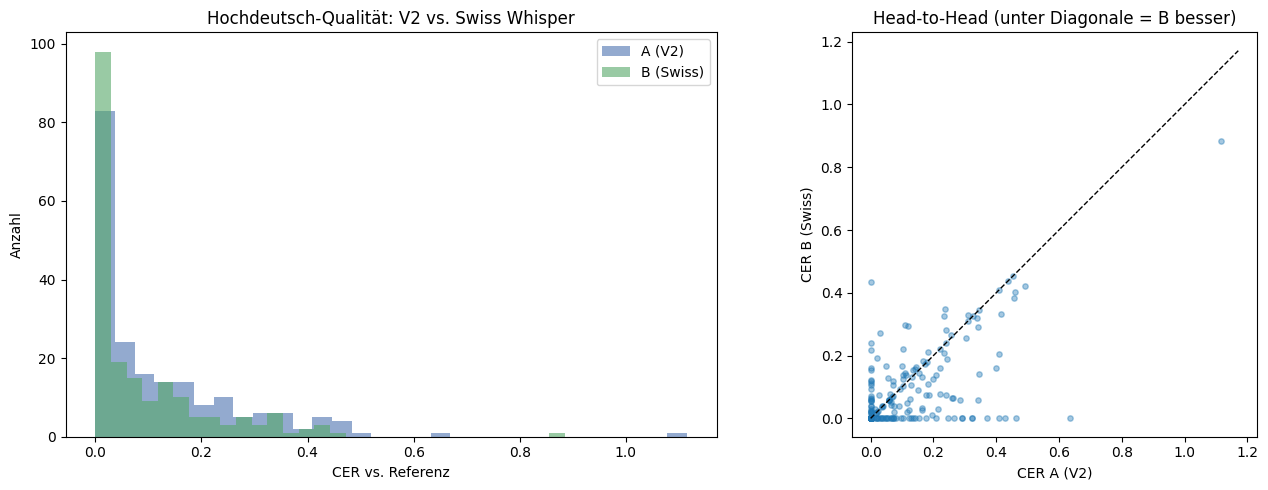

In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# CER-Histogramm A vs B
ax = axes[0]
ax.hist(df_out["cer_a_vs_ref"].dropna(), bins=30, alpha=0.6, label="A (V2)", color="#4C72B0")
ax.hist(df_out["cer_b_vs_ref"].dropna(), bins=30, alpha=0.6, label="B (Swiss)", color="#55A868")
ax.set_xlabel("CER vs. Referenz")
ax.set_ylabel("Anzahl")
ax.set_title("Hochdeutsch-Qualität: V2 vs. Swiss Whisper")
ax.legend()

# Scatter A vs B
ax2 = axes[1]
ax2.scatter(df_out["cer_a_vs_ref"], df_out["cer_b_vs_ref"], alpha=0.4, s=15)
lim = max(df_out["cer_a_vs_ref"].max(), df_out["cer_b_vs_ref"].max()) * 1.05
ax2.plot([0, lim], [0, lim], "k--", lw=1)
ax2.set_xlabel("CER A (V2)")
ax2.set_ylabel("CER B (Swiss)")
ax2.set_title("Head-to-Head (unter Diagonale = B besser)")
ax2.set_aspect("equal")

plt.tight_layout()
plt.show()

## 8. Stichprobe: Alle 4 Outputs nebeneinander

In [13]:
sample_rows = df_out.sample(n=min(10, len(df_out)), random_state=1)
for _, r in sample_rows.iterrows():
    print(f"📝 Referenz:      {r['sentence']}")
    print(f"🔵 A (V2 HD):     {r['A_v2_hd']}")
    print(f"🟢 B (Swiss HD):  {r['B_swiss_hd']}")
    print(f"🟡 C (W2V IPA):   {r['C_w2v_ipa'][:80]}")
    print(f"🟠 D (Wh. IPA):   {r['D_whisper_ipa'][:80]}")
    print("-" * 80)

📝 Referenz:      Danach begaben sich die Polizisten in die Bar.
🔵 A (V2 HD):     Danach begeben sich die Polizisten in die Bahn.
🟢 B (Swiss HD):  Danach begeben sich die Polizisten in die Bau.
🟡 C (W2V IPA):   d ɛ n oː x b ɛ ɡ ɛ r ə ts ɪ x p oː l iː ts iː ʃ t ɛ iː t b aʊ l
🟠 D (Wh. IPA):   ˈɪnɔx bəgˈɛvət zˈɪç pˌoːliːtsˈɪçtɛ ˈɪtbˌaʊ
--------------------------------------------------------------------------------
📝 Referenz:      Entweder der Demokrat oder der Republikaner gewinnt.
🔵 A (V2 HD):     Entweder der Demokrat oder der Republikaner gewinnt.
🟢 B (Swiss HD):  entweder der Demokrat oder der Republikaner gewinnt.
🟡 C (W2V IPA):   ɛ n t eː d ə d ə t eː m ʊ k ɾ a t oː d oː d ə r eː b ʊ b k l iː k a n ɔ k v y n 
🟠 D (Wh. IPA):   ˈɛnt ˈɛnt ˈɛn dˈɛmɔk ɾˈɑːtəl dˈɛɾ ɾɪbˈoːkˌlɪk ɣˈɑːn ˈɔk kˈwˌyːnt
--------------------------------------------------------------------------------
📝 Referenz:      Denn bei Müttern müsse der Arbeitgeber flexibler sein.
🔵 A (V2 HD):     Dem Bemühten muss der Arb